# Part A: Transfer Learning

## Importing Libraries

In [ ]:
# Data Handling and Preprocessing
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import random
import os


# Image and Visualisation
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F

# PyTorch and Torchvision
import torch
import torchvision
import torchvision.transforms as transforms
from torchsummary import summary
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torch import nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Set random seed for reproducibility
torch.manual_seed(42)

## Loading Data

### Obtaining labels for each class

In [ ]:
with open("/kaggle/input/food-101/food-101/meta/classes.txt", "r") as f:
    class_names = f.read().splitlines()

# Create mapping from index to class name
label_to_class = {idx: class_name for idx, class_name in enumerate(class_names)}
label_to_class

{0: 'apple_pie',
 1: 'baby_back_ribs',
 2: 'baklava',
 3: 'beef_carpaccio',
 4: 'beef_tartare',
 5: 'beet_salad',
 6: 'beignets',
 7: 'bibimbap',
 8: 'bread_pudding',
 9: 'breakfast_burrito',
 10: 'bruschetta',
 11: 'caesar_salad',
 12: 'cannoli',
 13: 'caprese_salad',
 14: 'carrot_cake',
 15: 'ceviche',
 16: 'cheesecake',
 17: 'cheese_plate',
 18: 'chicken_curry',
 19: 'chicken_quesadilla',
 20: 'chicken_wings',
 21: 'chocolate_cake',
 22: 'chocolate_mousse',
 23: 'churros',
 24: 'clam_chowder',
 25: 'club_sandwich',
 26: 'crab_cakes',
 27: 'creme_brulee',
 28: 'croque_madame',
 29: 'cup_cakes',
 30: 'deviled_eggs',
 31: 'donuts',
 32: 'dumplings',
 33: 'edamame',
 34: 'eggs_benedict',
 35: 'escargots',
 36: 'falafel',
 37: 'filet_mignon',
 38: 'fish_and_chips',
 39: 'foie_gras',
 40: 'french_fries',
 41: 'french_onion_soup',
 42: 'french_toast',
 43: 'fried_calamari',
 44: 'fried_rice',
 45: 'frozen_yogurt',
 46: 'garlic_bread',
 47: 'gnocchi',
 48: 'greek_salad',
 49: 'grilled_chees

### Reading Train and Test Image Paths

In [ ]:
# Read train & test image paths
with open("/kaggle/input/food-101/food-101/meta/train.txt", "r") as f:
    train_image_ids = f.read().splitlines()  

with open("/kaggle/input/food-101/food-101/meta/test.txt", "r") as f:
    test_image_ids = f.read().splitlines()  
    
# Extract labels (folder names) from image paths
y_data = [image_id.split("/")[0] for image_id in train_image_ids]  # Labels for training set
y_test = [image_id.split("/")[0] for image_id in test_image_ids]   # Labels for test set

# Construct full image paths
X_data = [f"/kaggle/input/food-101/food-101/images/{image_id}.jpg" for image_id in train_image_ids]  # Train image paths
X_test = [f"/kaggle/input/food-101/food-101/images/{image_id}.jpg" for image_id in test_image_ids]   # Test image paths

# Print samples
print("First 5 image paths (X_data):", X_data[:5])
print("First 5 labels (y_data):", y_data[:5])
print("First 5 image paths (X_test):", X_test[:5])
print("First 5 labels (y_test):", y_test[:5])


First 5 image paths (X_data): ['/kaggle/input/food-101/food-101/images/apple_pie/1005649.jpg', '/kaggle/input/food-101/food-101/images/apple_pie/1014775.jpg', '/kaggle/input/food-101/food-101/images/apple_pie/1026328.jpg', '/kaggle/input/food-101/food-101/images/apple_pie/1028787.jpg', '/kaggle/input/food-101/food-101/images/apple_pie/1043283.jpg']
First 5 labels (y_data): ['apple_pie', 'apple_pie', 'apple_pie', 'apple_pie', 'apple_pie']
First 5 image paths (X_test): ['/kaggle/input/food-101/food-101/images/apple_pie/1011328.jpg', '/kaggle/input/food-101/food-101/images/apple_pie/101251.jpg', '/kaggle/input/food-101/food-101/images/apple_pie/1034399.jpg', '/kaggle/input/food-101/food-101/images/apple_pie/103801.jpg', '/kaggle/input/food-101/food-101/images/apple_pie/1038694.jpg']
First 5 labels (y_test): ['apple_pie', 'apple_pie', 'apple_pie', 'apple_pie', 'apple_pie']


### Label Encoding

In [ ]:
# Fit LabelEncoder on ALL labels (train + test) to ensure consistency
label_encoder = LabelEncoder()
label_encoder.fit(y_data + y_test)

# Encode labels
y_data_encoded = label_encoder.transform(y_data)
y_test_encoded = label_encoder.transform(y_test)

# Print label mapping
print("Label Mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
print("First 5 Encoded Labels (y_data):", y_data_encoded[:5])
print("First 5 Encoded Labels (y_test):", y_test_encoded[:5])

Label Mapping: {'apple_pie': 0, 'baby_back_ribs': 1, 'baklava': 2, 'beef_carpaccio': 3, 'beef_tartare': 4, 'beet_salad': 5, 'beignets': 6, 'bibimbap': 7, 'bread_pudding': 8, 'breakfast_burrito': 9, 'bruschetta': 10, 'caesar_salad': 11, 'cannoli': 12, 'caprese_salad': 13, 'carrot_cake': 14, 'ceviche': 15, 'cheese_plate': 16, 'cheesecake': 17, 'chicken_curry': 18, 'chicken_quesadilla': 19, 'chicken_wings': 20, 'chocolate_cake': 21, 'chocolate_mousse': 22, 'churros': 23, 'clam_chowder': 24, 'club_sandwich': 25, 'crab_cakes': 26, 'creme_brulee': 27, 'croque_madame': 28, 'cup_cakes': 29, 'deviled_eggs': 30, 'donuts': 31, 'dumplings': 32, 'edamame': 33, 'eggs_benedict': 34, 'escargots': 35, 'falafel': 36, 'filet_mignon': 37, 'fish_and_chips': 38, 'foie_gras': 39, 'french_fries': 40, 'french_onion_soup': 41, 'french_toast': 42, 'fried_calamari': 43, 'fried_rice': 44, 'frozen_yogurt': 45, 'garlic_bread': 46, 'gnocchi': 47, 'greek_salad': 48, 'grilled_cheese_sandwich': 49, 'grilled_salmon': 50,

### Training, Validation and Testing Split

In [ ]:
# Split X_data into training (80%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_data, y_data_encoded, test_size=0.2, stratify=y_data_encoded, random_state=42
)

# Print dataset sizes
print(f"Training set: {len(X_train)} images")
print(f"Validation set: {len(X_val)} images")
print(f"Test set: {len(X_test)} images")

Training set: 60600 images
Validation set: 15150 images
Test set: 25250 images


## Data Augmentation

In [ ]:
# Define transformations
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224 (standard for CNNs)
    transforms.RandomHorizontalFlip(),  # Data augmentation
    transforms.RandomRotation(30),  # Random rotation
    transforms.ToTensor(),  # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### Custom Class to Obtain Images and Labels From the Food101 Dataset

In [ ]:
# Define custom dataset class for Food101 to obtain images and labels
# This class will be used to load images and labels for training and validation
class Food101Dataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self): # Need it for DataLoader
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")  # Ensure it's RGB

        # Apply transformation
        if self.transform:
            image = self.transform(image)

        # Get label
        label = self.labels[idx]

        return image, label

In [ ]:
# Create datasets
train_dataset = Food101Dataset(X_train, y_train, transform=transform_train)
val_dataset = Food101Dataset(X_val, y_val, transform=transform_test)
test_dataset = Food101Dataset(X_test, y_test_encoded, transform=transform_test)

## Loading Random Images

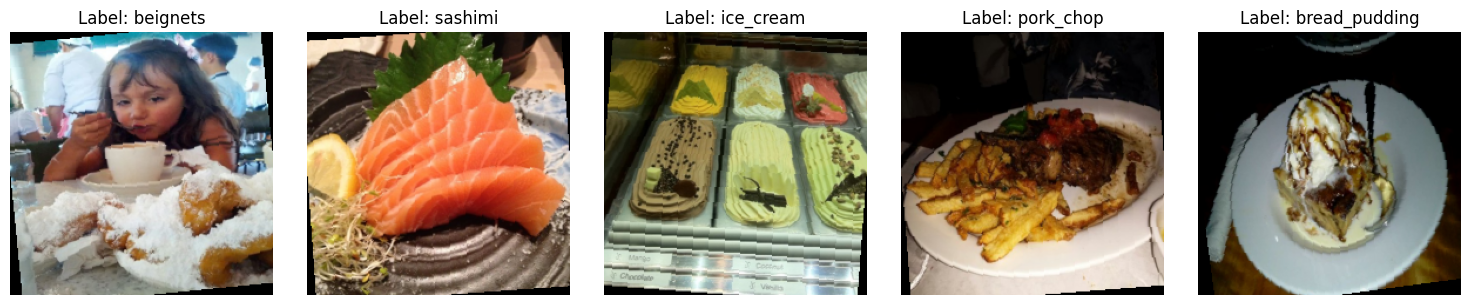

In [ ]:
# Load Random Images that are not normalized

# Define mean and std used in normalization
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

def unnormalize(tensor):
    return tensor * std[:, None, None] + mean[:, None, None]

# Randomly sample 5 images
indices = random.sample(range(len(train_dataset)), 5)

plt.figure(figsize=(15, 3))

for i, idx in enumerate(indices):
    image_tensor, label = train_dataset[idx]

    # Undo normalization
    image_tensor = unnormalize(image_tensor)

    # Clamp values to [0,1] in case they go out of range
    image_tensor = torch.clamp(image_tensor, 0, 1)

    # Convert back to PIL image for plotting
    image = F.to_pil_image(image_tensor)

    plt.subplot(1, 5, i+1)
    plt.imshow(image)
    plt.title(f"Label: {label_to_class[label]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Setup Dataloaders

In [ ]:
# Define batch size
batch_size = 128

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Check a sample batch
images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch labels:", labels[:5])

Batch image shape: torch.Size([128, 3, 224, 224])
Batch labels: tensor([36, 79, 61, 73, 97])


In [ ]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Load Pre-trained models

In [ ]:
# Load pretrained models
googlenet = models.googlenet(pretrained=True)  # GoogLeNet
mobilenet_v3 = models.mobilenet_v3_large(pretrained=True)  # MobileNet V3 (Large version)
resnet50 = models.resnet50(pretrained=True)  # ResNet50

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth
100%|██████████| 49.7M/49.7M [00:00<00:00, 162MB/s]
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 144MB/s]
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s]


### GoogLeNet Architecture

In [ ]:
print(googlenet)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

### MobilenetV3 Large Architecture

In [ ]:
print(mobilenet_v3)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

### Resnet50 Architecture

In [ ]:
print(resnet50)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Replacing Model Head and Freezing Pre-Trained Layers

### Fully Connected Layers for GoogLeNet, MobileNet V3 and Resnet50

In [ ]:
# GoogLeNet Last Layer
# Freeze all pre-trained layers
for param in googlenet.parameters():
    param.requires_grad = False

# Replace the final fully connected layer (fc) with a new head
googlenet.fc = nn.Sequential(
    nn.Linear(googlenet.fc.in_features, 512),   # First fully connected layer
    nn.ReLU(),                                 # Activation
    nn.Dropout(0.2),                            # Dropout for regularization
    nn.Linear(512, 256),                        # Second fully connected layer
    nn.ReLU(),                                 # Activation
    nn.Linear(256, 101)                         # Final output layer for 101 classes
)
new_googlenet = googlenet

In [ ]:
# MobileNet V3 Last Layer
# Freeze all pre-trained layers
for param in mobilenet_v3.parameters():
    param.requires_grad = False

# Replace the final fully connected layer (classifier) with a new head
mobilenet_v3.classifier[3] = nn.Sequential(
    nn.Linear(mobilenet_v3.classifier[3].in_features, 512),  # First fully connected layer
    nn.ReLU(),                                              # Activation
    nn.Dropout(0.2),                                         # Dropout for regularization
    nn.Linear(512, 256),                                     # Second fully connected layer
    nn.ReLU(),                                              # Activation
    nn.Linear(256, 101)                                      # Final output layer for 101 classes
)
new_mobilenet_v3 = mobilenet_v3

In [ ]:
# Resnet50 Last Layer
# Freeze all pre-trained layers
for param in resnet50.parameters():
    param.requires_grad = False

# Replace the final fully connected layer (fc) with a new head
resnet50.fc = nn.Sequential(
    nn.Linear(resnet50.fc.in_features, 512),   # First fully connected layer
    nn.ReLU(),                               # Activation
    nn.Dropout(0.2),                          # Dropout for regularization
    nn.Linear(512, 256),                      # Second fully connected layer
    nn.ReLU(),                               # Activation
    nn.Linear(256, 101)                       # Final output layer for 101 classes
)
new_resnet50 = resnet50

## Training and Evaluation of Each Model

In [ ]:
# Criterion and Optimizer
criterion = nn.CrossEntropyLoss()

optimizer_googlenet = optim.Adam(new_googlenet.parameters(), lr=0.001)
optimizer_mobilenet = optim.Adam(new_mobilenet_v3.parameters(), lr=0.001)
optimizer_resnet = optim.Adam(new_resnet50.parameters(), lr=0.001)


The following custom callback function is adapted from William So's 2025 Lab 4, Exercise 3 notebook.

In [ ]:
class CustomCallback:
    def __init__(self, early_stop_patience=5, reduce_lr_factor=0.2, reduce_lr_patience=3, reduce_lr_min_lr=0.0000001, checkpoint_path='checkpoint.pth', log_dir='logs'):

        # Parameters for early stopping and learning rate reduction
        self.early_stop_patience = early_stop_patience    # Patience for early stopping
        self.reduce_lr_factor = reduce_lr_factor          # Factor by which to reduce learning rate
        self.reduce_lr_patience = reduce_lr_patience      # Patience for reducing learning rate
        self.reduce_lr_min_lr = reduce_lr_min_lr          # Minimum learning rate
        self.checkpoint_path = checkpoint_path            # Path to save model checkpoints
        # self.log_dir = log_dir  # Directory for logging (if needed)

        self.early_stop_counter = 0                       # Counter to track epochs without improvement
        self.best_val_loss = float('inf')                 # Best validation loss

        self.optimizer = None                             # Placeholder for the optimizer
        self.scheduler = None                             # Placeholder for the LR scheduler

    def set_optimizer(self, optimizer):
        self.optimizer = optimizer                        # Set optimizer for training

    def on_epoch_end(self, epoch, val_loss):
        # Early Stopping: Check if the validation loss improved
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.early_stop_counter = 0                   # Reset counter if improvement is seen
        else:
            self.early_stop_counter += 1                  # Increment counter if no improvement

        # Trigger early stopping if no improvement for a defined number of epochs
        if self.early_stop_counter >= self.early_stop_patience:
            print("Early stopping triggered!")
            return True                                   #  Return True to signal stopping training

        # Adjust the learning rate if a plateau in validation loss is detected
        if self.scheduler is not None:
            self.scheduler.step(val_loss)                 # Adjust learning rate based on validation loss

        return False  # Continue training if conditions are not met

    def on_train_begin(self):
        # Initialize the ReduceLROnPlateau scheduler with the optimizer and parameters.
        self.scheduler = ReduceLROnPlateau(self.optimizer, mode='min', factor=self.reduce_lr_factor,patience=self.reduce_lr_patience, min_lr=self.reduce_lr_min_lr)

    def on_train_end(self):
        pass                  # Additional cleanup can be done here if needed

    def set_model(self, model):
        self.model = model    # Store the model reference

## Training and Evaluation: Googlenet

In [ ]:
# Move models to device
new_googlenet.to(device)

# Setting up the callback for GoogLeNet
callback_googlenet = CustomCallback()
callback_googlenet.set_optimizer(optimizer_googlenet)
callback_googlenet.set_model(new_googlenet)

# Set the learning rate scheduler in the callback
lr_scheduler = ReduceLROnPlateau(optimizer_googlenet, mode='min', factor=0.1, patience=3, min_lr=1e-6)

### Training - GoogLeNet

In [ ]:
# Initialize lists to store epoch-wise values
train_losses = []       # List to store training losses
train_accuracies = []   # List to store training accuracies
val_losses = []         # List to store validation losses
val_accuracies = []     # List to store validation accuracies

# Training loop
num_epochs = 10                     # Number of epochs for training
for epoch in range(num_epochs):

    # Training
    new_googlenet.train()             # Set the model to training mode
    running_train_loss = 0.0        # Accumulate training loss
    correct_train = 0               # Count correct predictions in training
    total_train = 0                 # Total training samples processed

    # Use tqdm for progress bar in training loop
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} - Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
        optimizer_googlenet.zero_grad()                                   # Reset gradients to zero
        outputs = new_googlenet(inputs)                           # Forward pass

        # Unpack logits if model returns tuple
        if isinstance(outputs, tuple):
            logits = outputs[0]
        else:
            logits = outputs

        loss = criterion(logits, labels)                        # Calculate loss
        loss.backward()                                         # Backward pass
        optimizer_googlenet.step()                                        # Update model parameters

        running_train_loss += loss.item() * inputs.size(0)      # Update accumulated loss
        _, predicted = torch.max(logits, 1)                     # Get predicted class indices
        total_train += labels.size(0)                           # Update total count
        correct_train += (predicted == labels).sum().item()     # Count correct predictions

    # Calculate epoch-wise training loss and accuracy
    epoch_train_loss = running_train_loss / len(train_loader.dataset)     # Average training loss
    train_accuracy = correct_train / total_train                          # Training accuracy

    # Validation
    new_googlenet.eval()              # Set the model to evaluation mode
    running_val_loss = 0.0          # Accumulate validation loss
    correct_val = 0                 # Count correct predictions in validation
    total_val = 0                   # Total validation samples processed

    # Disable gradient computation for validation
    with torch.no_grad():
        # Use tqdm for progress bar in validation loop
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} - Validation", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
            outputs = new_googlenet(inputs)                           # Forward pass
            if isinstance(outputs, tuple):
                logits = outputs[0]                                 # Unpack logits if model returns tuple
            else:
                logits = outputs
            loss = criterion(logits, labels)                        # Calculate loss

            running_val_loss += loss.item() * inputs.size(0)        # Accumulate validation loss
            _, predicted = torch.max(logits, 1)                     # Get predicted labels
            total_val += labels.size(0)                             # Increment total validation samples
            correct_val += (predicted == labels).sum().item()       # Increment correctly predicted validation samples

    # Compute average validation loss and accuracy for the epoch.
    epoch_val_loss = running_val_loss / len(val_loader.dataset)     # Average validation loss
    val_accuracy = correct_val / total_val                          # Validation accuracy

    # Append values to lists
    train_losses.append(epoch_train_loss)                           # Append training loss
    train_accuracies.append(train_accuracy)                         # Append training accuracy
    val_losses.append(epoch_val_loss)                               # Append validation loss
    val_accuracies.append(val_accuracy)                             # Append validation accuracy

    # Update learning rate scheduler based on validation loss.
    lr_scheduler.step(epoch_val_loss)                               # Adjust learning rate based on validation loss

    # Check for early stopping using the custom callback.
    if callback_googlenet.on_epoch_end(epoch, epoch_val_loss):
        break                                                       # Stop training if early stopping criterion is met

    # Print progress for the current epoch.
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')


Epoch [1/10], Train Loss: 3.4688, Train Accuracy: 0.1911, Val Loss: 2.8776, Val Accuracy: 0.2950


Epoch [2/10], Train Loss: 2.8855, Train Accuracy: 0.2955, Val Loss: 2.6237, Val Accuracy: 0.3514


Epoch [3/10], Train Loss: 2.7572, Train Accuracy: 0.3242, Val Loss: 2.5159, Val Accuracy: 0.3745


Epoch [4/10], Train Loss: 2.6772, Train Accuracy: 0.3409, Val Loss: 2.4786, Val Accuracy: 0.3871


Epoch [5/10], Train Loss: 2.6279, Train Accuracy: 0.3518, Val Loss: 2.4504, Val Accuracy: 0.3939


Epoch [6/10], Train Loss: 2.5850, Train Accuracy: 0.3592, Val Loss: 2.3732, Val Accuracy: 0.4148


Epoch [7/10], Train Loss: 2.5543, Train Accuracy: 0.3680, Val Loss: 2.3903, Val Accuracy: 0.4090


Epoch [8/10], Train Loss: 2.5330, Train Accuracy: 0.3706, Val Loss: 2.3647, Val Accuracy: 0.4094


Epoch [9/10], Train Loss: 2.5123, Train Accuracy: 0.3744, Val Loss: 2.3348, Val Accuracy: 0.4132


Epoch [10/10], Train Loss: 2.4918, Train Accuracy: 0.3806, Val Loss: 2.3203, Val Accuracy: 0.4224


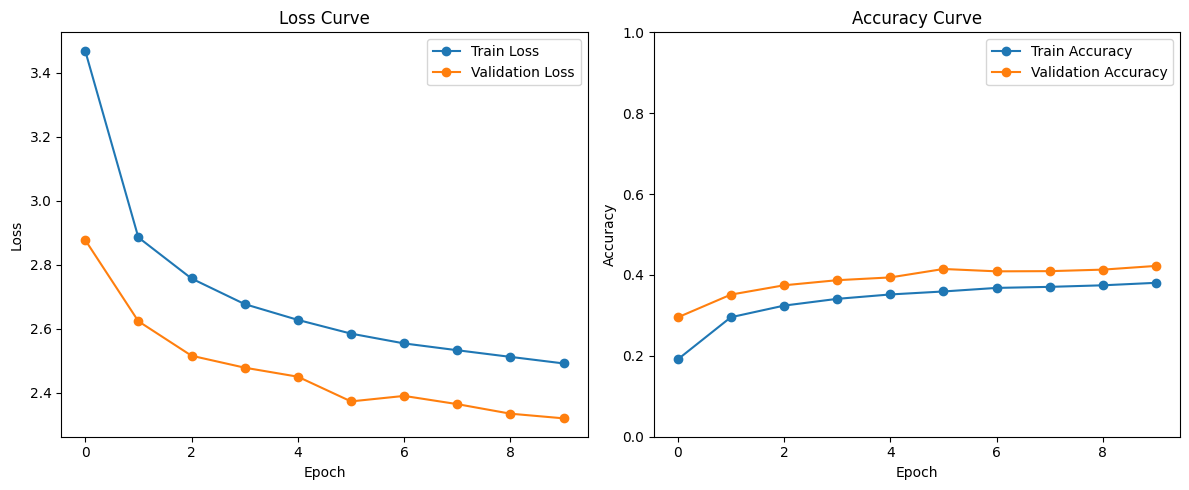

In [ ]:
# Plot Loss Curve and Accuracy curve
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', marker='o')
plt.plot(val_accuracies, label='Validation Accuracy', marker='o')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.legend()

plt.tight_layout()
plt.show()

### Testing - GoogLeNet

In [ ]:
# Set the model to evaluation mode and disable gradients for testing.
new_googlenet.eval()
test_correct = 0          # Counter for correct predictions in testing
test_total = 0            # Total test samples processed
test_running_loss = 0.0   # Accumulator for test loss

with torch.no_grad():                                           # Turn off gradients during evaluation
    for inputs, labels in test_loader:                          # Iterate through test data
        inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU
        outputs = new_googlenet(inputs)                           # Get model predictions

        if isinstance(outputs, tuple):
            logits = outputs[0]                                 # Unpack logits from model outputs if necessary
        else:
            logits = outputs
        loss = criterion(logits, labels)                        # Calculate loss

        test_running_loss += loss.item() * inputs.size(0)       # Update running test loss
        _, predicted = torch.max(logits, 1)                     # Get predicted labels
        test_total += labels.size(0)                            # Update total number of samples
        test_correct += (predicted == labels).sum().item()      # Update number of correctly predicted samples

# Calculate test loss and accuracy
test_loss = test_running_loss / len(test_loader.dataset)  # Average test loss
test_accuracy = test_correct / test_total                 # Test accuracy

# Print test results
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

Test Loss: 2.1182, Test Accuracy: 0.4630


## Training and Evaluation: Mobilenet v3

In [ ]:
# Move models to device
new_mobilenet_v3.to(device)

# Setting up the callback for GoogLeNet
callback_mobilenet = CustomCallback()
callback_mobilenet.set_optimizer(optimizer_mobilenet)
callback_mobilenet.set_model(new_mobilenet_v3)

# Set the learning rate scheduler in the callback
lr_scheduler = ReduceLROnPlateau(optimizer_mobilenet, mode='min', factor=0.1, patience=3, min_lr=1e-6)

### Training - Mobilenet V3

In [ ]:
# Initialize lists to store epoch-wise values
train_losses = []       # List to store training losses
train_accuracies = []   # List to store training accuracies
val_losses = []         # List to store validation losses
val_accuracies = []     # List to store validation accuracies

# Training loop
num_epochs = 10                     # Number of epochs for training
for epoch in range(num_epochs):

    # Training
    new_mobilenet_v3.train()             # Set the model to training mode
    running_train_loss = 0.0        # Accumulate training loss
    correct_train = 0               # Count correct predictions in training
    total_train = 0                 # Total training samples processed

    # Use tqdm for progress bar in training loop
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} - Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
        optimizer_mobilenet.zero_grad()                                   # Reset gradients to zero
        outputs = new_mobilenet_v3(inputs)                           # Forward pass

        # Unpack logits if model returns tuple
        if isinstance(outputs, tuple):
            logits = outputs[0]
        else:
            logits = outputs

        loss = criterion(logits, labels)                        # Calculate loss
        loss.backward()                                         # Backward pass
        optimizer_mobilenet.step()                                        # Update model parameters

        running_train_loss += loss.item() * inputs.size(0)      # Update accumulated loss
        _, predicted = torch.max(logits, 1)                     # Get predicted class indices
        total_train += labels.size(0)                           # Update total count
        correct_train += (predicted == labels).sum().item()     # Count correct predictions

    # Calculate epoch-wise training loss and accuracy
    epoch_train_loss = running_train_loss / len(train_loader.dataset)     # Average training loss
    train_accuracy = correct_train / total_train                          # Training accuracy

    # Validation
    new_mobilenet_v3.eval()              # Set the model to evaluation mode
    running_val_loss = 0.0          # Accumulate validation loss
    correct_val = 0                 # Count correct predictions in validation
    total_val = 0                   # Total validation samples processed

    # Disable gradient computation for validation
    with torch.no_grad():
        # Use tqdm for progress bar in validation loop
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} - Validation", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
            outputs = new_mobilenet_v3(inputs)                           # Forward pass
            if isinstance(outputs, tuple):
                logits = outputs[0]                                 # Unpack logits if model returns tuple
            else:
                logits = outputs
            loss = criterion(logits, labels)                        # Calculate loss

            running_val_loss += loss.item() * inputs.size(0)        # Accumulate validation loss
            _, predicted = torch.max(logits, 1)                     # Get predicted labels
            total_val += labels.size(0)                             # Increment total validation samples
            correct_val += (predicted == labels).sum().item()       # Increment correctly predicted validation samples

    # Compute average validation loss and accuracy for the epoch.
    epoch_val_loss = running_val_loss / len(val_loader.dataset)     # Average validation loss
    val_accuracy = correct_val / total_val                          # Validation accuracy

    # Append values to lists
    train_losses.append(epoch_train_loss)                           # Append training loss
    train_accuracies.append(train_accuracy)                         # Append training accuracy
    val_losses.append(epoch_val_loss)                               # Append validation loss
    val_accuracies.append(val_accuracy)                             # Append validation accuracy

    # Update learning rate scheduler based on validation loss.
    lr_scheduler.step(epoch_val_loss)                               # Adjust learning rate based on validation loss

    # Check for early stopping using the custom callback.
    if callback_mobilenet.on_epoch_end(epoch, epoch_val_loss):
        break                                                       # Stop training if early stopping criterion is met

    # Print progress for the current epoch.
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')


Epoch [1/10], Train Loss: 2.7470, Train Accuracy: 0.3389, Val Loss: 2.2008, Val Accuracy: 0.4475


Epoch [2/10], Train Loss: 2.1875, Train Accuracy: 0.4513, Val Loss: 2.0667, Val Accuracy: 0.4816


Epoch [3/10], Train Loss: 2.0422, Train Accuracy: 0.4802, Val Loss: 2.0177, Val Accuracy: 0.4916


Epoch [4/10], Train Loss: 1.9482, Train Accuracy: 0.5006, Val Loss: 1.9866, Val Accuracy: 0.5006


Epoch [5/10], Train Loss: 1.8830, Train Accuracy: 0.5125, Val Loss: 1.9891, Val Accuracy: 0.5036


Epoch [6/10], Train Loss: 1.8168, Train Accuracy: 0.5271, Val Loss: 1.9685, Val Accuracy: 0.5067


Epoch [7/10], Train Loss: 1.7769, Train Accuracy: 0.5384, Val Loss: 1.9694, Val Accuracy: 0.5073


Epoch [8/10], Train Loss: 1.7273, Train Accuracy: 0.5485, Val Loss: 1.9701, Val Accuracy: 0.5094


Epoch [9/10], Train Loss: 1.6864, Train Accuracy: 0.5539, Val Loss: 1.9810, Val Accuracy: 0.5056


Epoch [10/10], Train Loss: 1.6575, Train Accuracy: 0.5604, Val Loss: 1.9795, Val Accuracy: 0.5103


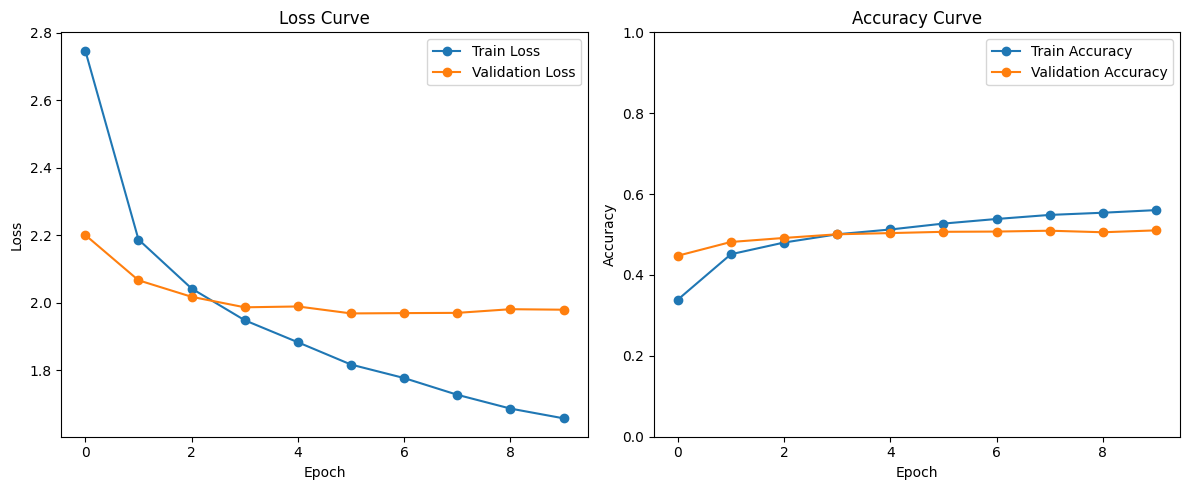

In [ ]:
# Plot Loss Curve and Accuracy curve
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', marker='o')
plt.plot(val_accuracies, label='Validation Accuracy', marker='o')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.legend()

plt.tight_layout()
plt.show()

### Testing - Mobilenet V3

In [ ]:
# Set the model to evaluation mode and disable gradients for testing.
new_mobilenet_v3.eval()
test_correct = 0          # Counter for correct predictions in testing
test_total = 0            # Total test samples processed
test_running_loss = 0.0   # Accumulator for test loss

with torch.no_grad():                                           # Turn off gradients during evaluation
    for inputs, labels in test_loader:                          # Iterate through test data
        inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU
        outputs = new_mobilenet_v3(inputs)                           # Get model predictions

        if isinstance(outputs, tuple):
            logits = outputs[0]                                 # Unpack logits from model outputs if necessary
        else:
            logits = outputs
        loss = criterion(logits, labels)                        # Calculate loss

        test_running_loss += loss.item() * inputs.size(0)       # Update running test loss
        _, predicted = torch.max(logits, 1)                     # Get predicted labels
        test_total += labels.size(0)                            # Update total number of samples
        test_correct += (predicted == labels).sum().item()      # Update number of correctly predicted samples

# Calculate test loss and accuracy
test_loss = test_running_loss / len(test_loader.dataset)  # Average test loss
test_accuracy = test_correct / test_total                 # Test accuracy

# Print test results
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

Test Loss: 1.7255, Test Accuracy: 0.5543


## Training and Evaluation: Resnet50

In [ ]:
# Move models to device
new_resnet50.to(device)

# Setting up the callback for GoogLeNet
callback_resnet = CustomCallback()
callback_resnet.set_optimizer(optimizer_resnet)
callback_resnet.set_model(new_resnet50)

# Set the learning rate scheduler in the callback
lr_scheduler = ReduceLROnPlateau(optimizer_resnet, mode='min', factor=0.1, patience=3, min_lr=1e-6)

### Training - Resnet50

In [ ]:
# Initialize lists to store epoch-wise values
train_losses = []       # List to store training losses
train_accuracies = []   # List to store training accuracies
val_losses = []         # List to store validation losses
val_accuracies = []     # List to store validation accuracies

# Training loop
num_epochs = 10                     # Number of epochs for training
for epoch in range(num_epochs):

    # Training
    new_resnet50.train()             # Set the model to training mode
    running_train_loss = 0.0        # Accumulate training loss
    correct_train = 0               # Count correct predictions in training
    total_train = 0                 # Total training samples processed

    # Use tqdm for progress bar in training loop
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} - Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
        optimizer_resnet.zero_grad()                                   # Reset gradients to zero
        outputs = new_resnet50(inputs)                           # Forward pass

        # Unpack logits if model returns tuple
        if isinstance(outputs, tuple):
            logits = outputs[0]
        else:
            logits = outputs

        loss = criterion(logits, labels)                        # Calculate loss
        loss.backward()                                         # Backward pass
        optimizer_resnet.step()                                        # Update model parameters

        running_train_loss += loss.item() * inputs.size(0)      # Update accumulated loss
        _, predicted = torch.max(logits, 1)                     # Get predicted class indices
        total_train += labels.size(0)                           # Update total count
        correct_train += (predicted == labels).sum().item()     # Count correct predictions

    # Calculate epoch-wise training loss and accuracy
    epoch_train_loss = running_train_loss / len(train_loader.dataset)     # Average training loss
    train_accuracy = correct_train / total_train                          # Training accuracy

    # Validation
    new_resnet50.eval()              # Set the model to evaluation mode
    running_val_loss = 0.0          # Accumulate validation loss
    correct_val = 0                 # Count correct predictions in validation
    total_val = 0                   # Total validation samples processed

    # Disable gradient computation for validation
    with torch.no_grad():
        # Use tqdm for progress bar in validation loop
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} - Validation", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
            outputs = new_resnet50(inputs)                           # Forward pass
            if isinstance(outputs, tuple):
                logits = outputs[0]                                 # Unpack logits if model returns tuple
            else:
                logits = outputs
            loss = criterion(logits, labels)                        # Calculate loss

            running_val_loss += loss.item() * inputs.size(0)        # Accumulate validation loss
            _, predicted = torch.max(logits, 1)                     # Get predicted labels
            total_val += labels.size(0)                             # Increment total validation samples
            correct_val += (predicted == labels).sum().item()       # Increment correctly predicted validation samples

    # Compute average validation loss and accuracy for the epoch.
    epoch_val_loss = running_val_loss / len(val_loader.dataset)     # Average validation loss
    val_accuracy = correct_val / total_val                          # Validation accuracy

    # Append values to lists
    train_losses.append(epoch_train_loss)                           # Append training loss
    train_accuracies.append(train_accuracy)                         # Append training accuracy
    val_losses.append(epoch_val_loss)                               # Append validation loss
    val_accuracies.append(val_accuracy)                             # Append validation accuracy

    # Update learning rate scheduler based on validation loss.
    lr_scheduler.step(epoch_val_loss)                               # Adjust learning rate based on validation loss

    # Check for early stopping using the custom callback.
    if callback_resnet.on_epoch_end(epoch, epoch_val_loss):
        break                                                       # Stop training if early stopping criterion is met

    # Print progress for the current epoch.
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')


Epoch [1/10], Train Loss: 3.2679, Train Accuracy: 0.2239, Val Loss: 2.6359, Val Accuracy: 0.3409


Epoch [2/10], Train Loss: 2.5698, Train Accuracy: 0.3583, Val Loss: 2.3615, Val Accuracy: 0.4076


Epoch [3/10], Train Loss: 2.4172, Train Accuracy: 0.3929, Val Loss: 2.2167, Val Accuracy: 0.4381


Epoch [4/10], Train Loss: 2.3250, Train Accuracy: 0.4146, Val Loss: 2.1576, Val Accuracy: 0.4519


Epoch [5/10], Train Loss: 2.2667, Train Accuracy: 0.4257, Val Loss: 2.1515, Val Accuracy: 0.4525


Epoch [6/10], Train Loss: 2.2194, Train Accuracy: 0.4368, Val Loss: 2.1003, Val Accuracy: 0.4690


Epoch [7/10], Train Loss: 2.1848, Train Accuracy: 0.4434, Val Loss: 2.0871, Val Accuracy: 0.4667


Epoch [8/10], Train Loss: 2.1521, Train Accuracy: 0.4502, Val Loss: 2.0648, Val Accuracy: 0.4747


Epoch [9/10], Train Loss: 2.1267, Train Accuracy: 0.4587, Val Loss: 2.0442, Val Accuracy: 0.4780


Epoch [10/10], Train Loss: 2.0990, Train Accuracy: 0.4608, Val Loss: 2.0570, Val Accuracy: 0.4776


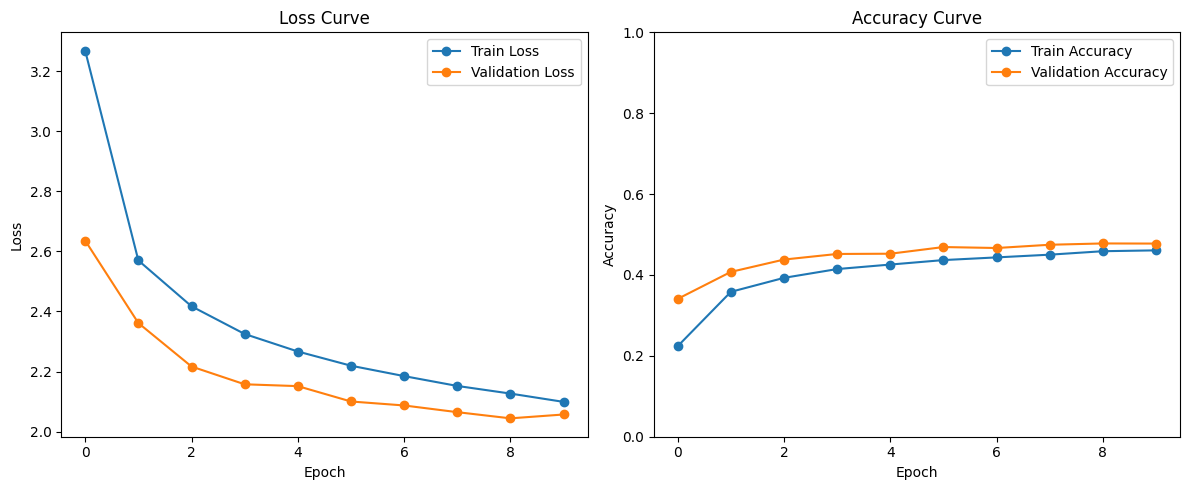

In [ ]:
# Plot Loss Curve and Accuracy curve
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', marker='o')
plt.plot(val_accuracies, label='Validation Accuracy', marker='o')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.legend()

plt.tight_layout()
plt.show()

### Testing - Resnet50

In [ ]:
# Set the model to evaluation mode and disable gradients for testing.
new_resnet50.eval()
test_correct = 0          # Counter for correct predictions in testing
test_total = 0            # Total test samples processed
test_running_loss = 0.0   # Accumulator for test loss

with torch.no_grad():                                           # Turn off gradients during evaluation
    for inputs, labels in test_loader:                          # Iterate through test data
        inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU
        outputs = new_resnet50(inputs)                           # Get model predictions

        if isinstance(outputs, tuple):
            logits = outputs[0]                                 # Unpack logits from model outputs if necessary
        else:
            logits = outputs
        loss = criterion(logits, labels)                        # Calculate loss

        test_running_loss += loss.item() * inputs.size(0)       # Update running test loss
        _, predicted = torch.max(logits, 1)                     # Get predicted labels
        test_total += labels.size(0)                            # Update total number of samples
        test_correct += (predicted == labels).sum().item()      # Update number of correctly predicted samples

# Calculate test loss and accuracy
test_loss = test_running_loss / len(test_loader.dataset)  # Average test loss
test_accuracy = test_correct / test_total                 # Test accuracy

# Print test results
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

Test Loss: 1.8236, Test Accuracy: 0.5205


## Conclusion

Based on the experimental results over 10 training epochs, MobileNetV3 outperforms both GoogLeNet and ResNet50 in terms of overall accuracy and loss. It achieves the highest test accuracy of 55.43% and the lowest test loss of 1.7255, indicating better generalisation to unseen data. While ResNet50 shows competitive performance with a final test accuracy of 52.05%, MobileNetV3 consistently demonstrates faster convergence and better validation accuracy throughout training. GoogLeNet, although improving steadily, lags behind with a lower test accuracy of 46.30%. Therefore, MobileNetV3 is the most effective model among the three for this classification task.